<a href="https://colab.research.google.com/github/koigs/centrality/blob/main/Analises_Eyetracking_IC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.animation import FuncAnimation,PillowWriter
from PIL import Image
import IPython.display as display
import numpy as np
import seaborn as sns
import matplotlib.patches as patches
import matplotlib.colors as mcolors

Mounted at /content/drive


In [3]:
alunos = pd.read_csv("/content/drive/MyDrive/(IC) TROG/TROG/Alunos 2020 & 2021.csv")

alunos["Nome"] = ["Aluno " + str(i) for i in range(1, len(alunos) + 1)]

In [4]:
ids = {}
for index, row in alunos.iterrows():
    id_v20 = int(row['ID1_V'])
    id_l20 = int(row['ID1_L'])
    id_v21 = int(row['ID2_V'])
    id_l21 = int(row['ID2_L'])
    nome = row['Nome']
    ids[nome] = {"IDV_20": id_v20, "IDL_20": id_l20, "IDV_21": id_v21, "IDL_21": id_l21}

In [5]:

alunos

,Nome,Alfatech,ID1_V,ID1_L,ID2_V,ID2_L
0,Aluno 1,1,47,44,131,103
1,Aluno 2,0,61,58,133,105
2,Aluno 3,0,89,84,130,102
3,Aluno 4,0,11,9,138,109
4,Aluno 5,0,79,75,136,107
5,Aluno 6,0,66,63,140,110
6,Aluno 7,0,53,50,141,111
7,Aluno 8,0,54,51,146,115
8,Aluno 9,0,55,52,129,101


In [6]:
ids

{'Aluno 1': {'IDV_20': 47, 'IDL_20': 44, 'IDV_21': 131, 'IDL_21': 103},
 'Aluno 2': {'IDV_20': 61, 'IDL_20': 58, 'IDV_21': 133, 'IDL_21': 105},
 'Aluno 3': {'IDV_20': 89, 'IDL_20': 84, 'IDV_21': 130, 'IDL_21': 102},
 'Aluno 4': {'IDV_20': 11, 'IDL_20': 9, 'IDV_21': 138, 'IDL_21': 109},
 'Aluno 5': {'IDV_20': 79, 'IDL_20': 75, 'IDV_21': 136, 'IDL_21': 107},
 'Aluno 6': {'IDV_20': 66, 'IDL_20': 63, 'IDV_21': 140, 'IDL_21': 110},
 'Aluno 7': {'IDV_20': 53, 'IDL_20': 50, 'IDV_21': 141, 'IDL_21': 111},
 'Aluno 8': {'IDV_20': 54, 'IDL_20': 51, 'IDV_21': 146, 'IDL_21': 115},
 'Aluno 9': {'IDV_20': 55, 'IDL_20': 52, 'IDV_21': 129, 'IDL_21': 101}}

In [7]:
acertos = pd.read_excel("/content/drive/MyDrive/(IC) TROG/TROG/acertos - 2020 e 2021 L e V.xlsx", sheet_name='acertos')

acertos.rename(columns={'Nome Criança': 'ID'}, inplace=True)

nomes_unicos = acertos['ID'].unique()
mapeamento = {nome: f'P {i+1}' for i, nome in enumerate(nomes_unicos)}
acertos['ID'] = acertos['ID'].map(mapeamento)

resultado = acertos.groupby('ID')[['Acerto V_20', 'Acerto L_20',"Acerto V_21","Acerto L_21"]].sum().reset_index()

In [8]:
acertos

,Item,ID,Alfatech,ID1_V,ID1_L,Série_20,Resposta V_20,Resposta L_20,Acerto V_20,Acerto L_20,ID2_V,ID2_L,Resposta V_21,Resposta L_21,Acerto V_21,Acerto L_21
0,1,P 1,1,47,44,3,1,1,1,1,131,103,1,2.0,1,0
1,2,P 1,1,47,44,3,4,2,1,0,131,103,4,3.0,1,1
2,3,P 1,1,47,44,3,2,1,1,0,131,103,2,1.0,1,0
3,4,P 1,1,47,44,3,2,1,0,1,131,103,2,1.0,0,1
4,5,P 1,1,47,44,3,3,2,1,1,131,103,3,3.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,8,P 9,0,55,52,3,4,1,0,1,129,101,1,1.0,1,1
104,9,P 9,0,55,52,3,4,3,1,1,129,101,4,3.0,1,1
105,10,P 9,0,55,52,3,3,3,0,1,129,101,2,3.0,1,1
106,11,P 9,0,55,52,3,1,4,1,1,129,101,1,1.0,1,0


In [9]:
resultado

,ID,Acerto V_20,Acerto L_20,Acerto V_21,Acerto L_21
0,P 1,9,6,6,4
1,P 2,12,7,8,5
2,P 3,8,11,9,11
3,P 4,10,7,10,1
4,P 5,8,7,10,7
5,P 6,11,7,9,8
6,P 7,11,8,11,11
7,P 8,7,6,10,6
8,P 9,10,11,12,7


In [23]:
def df_teste(teste, ano, alunos):

    linkG = "drive/MyDrive/(IC) TROG/TROG/Dados TROG Lido/"
    link = "drive/MyDrive/ufabc/ET_2020_2021_CS/data_lido/"
    file = f"{ano}/csv/{teste} {ano}.csv"
    file_path = linkG+file
    teste_df = pd.read_csv(file_path, sep=";")

    teste_df.rename(columns={'Name': 'ID'}, inplace=True)
    teste_df['ID'] = teste_df['ID'].astype(str).str.extract('(\d+)')
    teste_df['ID'] = pd.to_numeric(teste_df['ID'], errors='coerce')

    ano_chave = 'ID1_L' if ano == 2020 else 'ID2_L'

    for id, row in alunos.iterrows():
        id_aluno = row[ano_chave]
        nome_aluno = row['Nome']

        aluno_df = teste_df[teste_df["ID"] == id_aluno].copy()

        if aluno_df.empty:
            continue
        aluno_df.insert(aluno_df.columns.get_loc('ID'), 'aluno', nome_aluno)

        nome_arquivo = link+f"{teste}_{ano}_{nome_aluno.replace(' ', '_')}.csv"

        aluno_df.to_csv(nome_arquivo, index=False)

    return teste_df[teste_df['ID'].isin(alunos[ano_chave])]

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_542/2288922231.py:10: SyntaxWarning: invalid escape sequence '\d'
  teste_df['ID'] = teste_df['ID'].astype(str).str.extract('(\d+)')


In [24]:
testes = ['A1','A2', 'C1','C2','D1','D3','K1','K4','Q2','Q3','S1','S3']
testes_data = {}
for teste in testes:
    testes_data[teste+"_"+str(2020)] =  df_teste(teste,2020,alunos)
    testes_data[teste+"_"+str(2021)] = df_teste(teste,2021,alunos)

/tmp/ipykernel_542/2288922231.py:7: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  teste_df = pd.read_csv(file_path, sep=";")


# Tempo

In [26]:
tempo_medio = {}
ano = 2020
link = "drive/MyDrive/ufabc/ET_2020_2021_CS/data_lido/"

for aluno in range(1,10):
    m = 0
    c = 0
    for teste in testes:
        file = link+f"{teste}_{ano}_Aluno_{aluno}.csv"
        df_aluno = pd.read_csv(file)
        t = df_aluno.Time.max()/1000
        m += t
        c += 1
    tempo_medio["P "+str(aluno)]= m/c

In [27]:
resultado['Tempo_20'] = resultado['ID'].map(tempo_medio)
resultado

,ID,Acerto V_20,Acerto L_20,Acerto V_21,Acerto L_21,Tempo_20
0,P 1,9,6,6,4,40.597250
1,P 2,12,7,8,5,7.208000
2,P 3,8,11,9,11,14.146250
3,P 4,10,7,10,1,7.542250
4,P 5,8,7,10,7,7.318750
5,P 6,11,7,9,8,9.846083
6,P 7,11,8,11,11,10.558583
7,P 8,7,6,10,6,33.702000
8,P 9,10,11,12,7,13.654167


-0.34237138631237496


Text(0.5, 1.0, 'Tempo médio e acertos em 2020')

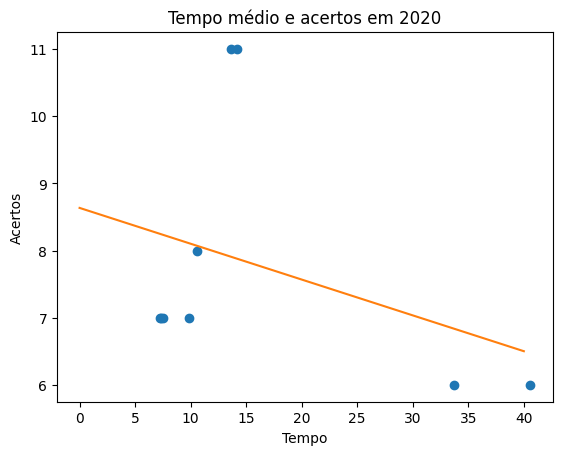

In [28]:
print(resultado["Acerto L_20"].corr(resultado["Tempo_20"]))
(a,b) = np.polyfit(resultado["Tempo_20"],resultado["Acerto L_20"],1)
plt.plot(resultado["Tempo_20"],resultado["Acerto L_20"],"o")
x = np.array([0,40])
y = a*x + b
plt.plot(x,y)
plt.xlabel("Tempo")
plt.ylabel("Acertos")
plt.title("Tempo médio e acertos em 2020")

In [30]:
tempo_medio = {}
aluno = 1
ano = 2021
link = "drive/MyDrive/ufabc/ET_2020_2021_CS/data_lido/"
for aluno in range(1,10):
    m = 0
    c = 0
    for teste in testes:
        file = link+f"{teste}_{ano}_Aluno_{aluno}.csv"
        df_aluno = pd.read_csv(file)
        t = df_aluno.Time.max()/1000
        m += t
        c += 1
    tempo_medio["P "+str(aluno)]= m/c

In [31]:
resultado['Tempo_21'] = resultado['ID'].map(tempo_medio)
resultado

,ID,Acerto V_20,Acerto L_20,Acerto V_21,Acerto L_21,Tempo_20,Tempo_21
0,P 1,9,6,6,4,40.597250,25.474667
1,P 2,12,7,8,5,7.208000,39.715583
2,P 3,8,11,9,11,14.146250,9.672750
3,P 4,10,7,10,1,7.542250,NaN
4,P 5,8,7,10,7,7.318750,7.522750
5,P 6,11,7,9,8,9.846083,7.804250
6,P 7,11,8,11,11,10.558583,6.632583
7,P 8,7,6,10,6,33.702000,27.487500
8,P 9,10,11,12,7,13.654167,10.803833


In [ ]:
print(resultado["Acerto L_21"].corr(resultado["Tempo_21"]))
(a,b) = np.polyfit(resultado["Tempo_21"],resultado["Acerto L_21"],1)

Text(0, 0.5, 'Acertos')

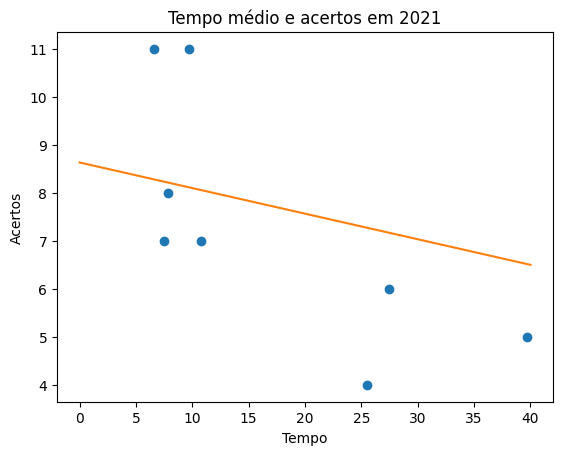

In [33]:
plt.plot(resultado["Tempo_21"],resultado["Acerto L_21"],"o")
x = np.array([0,40])
y = a*x + b
plt.plot(x,y)
plt.title("Tempo médio e acertos em 2021")
plt.xlabel("Tempo")
plt.ylabel("Acertos")

([<matplotlib.axis.XTick at 0x79e61d072180>,
 [Text(2020, 0, '2020'), Text(2021, 0, '2021')])

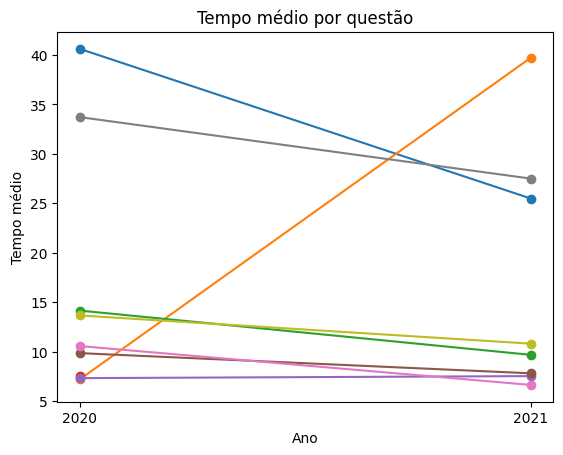

In [34]:
for index,row in resultado.iterrows():
    plt.plot([2020,2021],[row["Tempo_20"],row["Tempo_21"]],"o-")
plt.title("Tempo médio por questão")
plt.xlabel("Ano")
plt.ylabel("Tempo médio")
plt.xticks([2020,2021])


In [35]:
print(resultado["Tempo_20"].median())
print(resultado["Tempo_21"].median())

10.558583333333333
10.238291666666665


# Tempo de fixação na frase

In [36]:
aluno = 1
teste = testes[0]
ano = 2020
aoi = {}

for aluno in range(1,10):
    aoi[aluno]={2020:[],2021:[]}
    for ano in [2020,2021]:
        aoi[aluno][ano] = {1:0.0,2:0.0,3:0.0,4:0.0,5:0.0,6:0.0,7:0.0}
        for teste in testes:
            file = link+f"{teste}_{ano}_Aluno_{aluno}.csv"
            df_aluno = pd.read_csv(file)
            df_aluno['timegap_next'] = df_aluno['Timegap'].shift(-1)
            for index, row in df_aluno.iterrows():
                aois = row["AoI"].split(",")
                 #print(aois)
                for aoi_raw in aois:
                    a = str(aoi_raw)
                    if a != "-":
                        a = int(aoi_raw)
                        a_simple = a
                        if a > 9:
                            a_simple = a//10
                        try:
                            v = float(row["timegap_next"])
                            if v > 0:
                                aoi[aluno][ano][a_simple] += v
                                #print(a_simple,v)
                        except:
                            print("Invalid",a_simple,row["timegap_next"])
    print(aoi[aluno][ano])

{1: 24280.0, 2: 50082.0, 3: 29183.0, 4: 39996.0, 5: 13570.0, 6: 21721.0, 7: 295718.0}
{1: 4725.0, 2: 48437.0, 3: 45391.0, 4: 30914.0, 5: 34502.0, 6: 100645.0, 7: 177490.0}
{1: 8432.0, 2: 15488.0, 3: 11779.0, 4: 9904.0, 5: 6113.0, 6: 18084.0, 7: 105698.0}
{1: 9543.0, 2: 34745.0, 3: 6052.0, 4: 22151.0, 5: 9758.0, 6: 7203.0, 7: 114213.0}
{1: 3040.0, 2: 7027.0, 3: 14844.0, 4: 15429.0, 5: 6998.0, 6: 7064.0, 7: 55601.0}
{1: 6563.0, 2: 12435.0, 3: 19194.0, 4: 7603.0, 5: 8588.0, 6: 11117.0, 7: 72821.0}
{1: 6929.0, 2: 13426.0, 3: 13496.0, 4: 10064.0, 5: 5555.0, 6: 7862.0, 7: 75479.0}
{1: 34307.0, 2: 66828.0, 3: 13973.0, 4: 14682.0, 5: 13259.0, 6: 20960.0, 7: 483621.0}
{1: 17872.0, 2: 27600.0, 3: 12816.0, 4: 8497.0, 5: 3273.0, 6: 11638.0, 7: 163977.0}


In [37]:
tempo_frase20 = {}
tempo_frase21 = {}

for aluno in range(1,10):
    s = np.array(list(aoi[aluno][2020].values())).sum()
    s7 = aoi[aluno][2020][7]
    tempo_frase20["P "+str(aluno)] = s7/s*100
    s = np.array(list(aoi[aluno][2021].values())).sum()
    s7 = aoi[aluno][2021][7]
    tempo_frase21["P "+str(aluno)] = s7/s*100

resultado['Tempo_frase_20'] = resultado['ID'].map(tempo_frase20)
resultado['Tempo_frase_21'] = resultado['ID'].map(tempo_frase21)
resultado


,ID,Acerto V_20,Acerto L_20,Acerto V_21,Acerto L_21,Tempo_20,Tempo_21,Tempo_frase_20,Tempo_frase_21
0,P 1,9,6,6,4,40.597250,25.474667,63.162476,62.315457
1,P 2,12,7,8,5,7.208000,39.715583,61.359582,40.146662
2,P 3,8,11,9,11,14.146250,9.672750,66.479289,60.227467
3,P 4,10,7,10,1,7.542250,NaN,43.944074,56.078855
4,P 5,8,7,10,7,7.318750,7.522750,53.881610,50.544985
5,P 6,11,7,9,8,9.846083,7.804250,52.285990,52.646381
6,P 7,11,8,11,11,10.558583,6.632583,55.701699,56.831889
7,P 8,7,6,10,6,33.702000,27.487500,76.118277,74.675509
8,P 9,10,11,12,7,13.654167,10.803833,67.291785,66.746040


In [38]:
print(resultado["Tempo_frase_20"].corr(resultado["Acerto L_20"]))
print(resultado["Tempo_frase_21"].corr(resultado["Acerto L_21"]))
print(resultado["Tempo_frase_21"].corr(resultado["Tempo_frase_20"]))

0.21185063389537356
0.06263576661629756
0.6021501129991933


([<matplotlib.axis.XTick at 0x79e61c794da0>,
 [Text(2020, 0, '2020'), Text(2021, 0, '2021')])

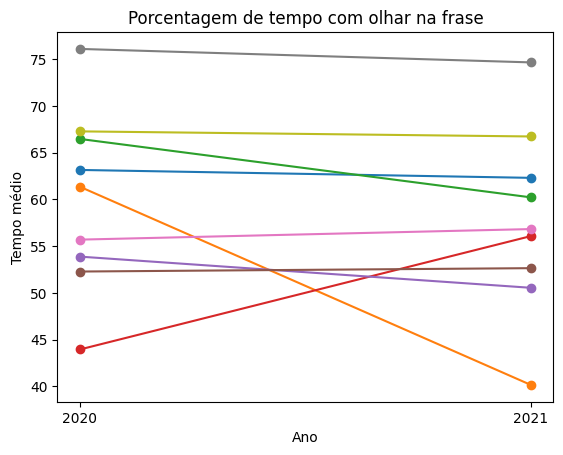

In [39]:
for index,row in resultado.iterrows():
    plt.plot([2020,2021],[row["Tempo_frase_20"],row["Tempo_frase_21"]],"o-")
plt.title("Porcentagem de tempo com olhar na frase")
plt.xlabel("Ano")
plt.ylabel("Tempo médio")
plt.xticks([2020,2021])

# Sacadas

In [40]:
import pandas as pd
import numpy as np

def detect_saccades(df, vel_thresh=10, min_dur=10, max_dur=100):
    dt = df['Timegap'][1:] / 1000.0
    dx, dy = np.diff(df['X']), np.diff(df['Y'])
    vel = np.sqrt((dx/dt)**2 + (dy/dt)**2)

    saccades = []
    in_saccade = False
    start = 0

    for i, v in enumerate(vel > vel_thresh):
        if v and not in_saccade:
            start, in_saccade = i, True
        elif not v and in_saccade:
            duration = df['Time'].iloc[i+1] - df['Time'].iloc[start+1]
            if min_dur <= duration <= max_dur:
                saccades.append({
                    'start': df['Time'].iloc[start+1],
                    'end': df['Time'].iloc[i+1],
                    'duration': duration,
                    'amplitude': np.sqrt((df['X'].iloc[i+1] - df['X'].iloc[start+1])**2 +
                                       (df['Y'].iloc[i+1] - df['Y'].iloc[start+1])**2)
                })
            in_saccade = False

    return len(saccades), pd.DataFrame(saccades)



In [42]:
saccade = {2020:{},2021:{}}

for aluno in range(1,10):
    for ano in [2020,2021]:
        saccade[ano]["P "+str(aluno)] = 0
        for teste in testes:
            link = "drive/MyDrive/ufabc/ET_2020_2021_CS/data_lido/"
            file = link+f"{teste}_{ano}_Aluno_{aluno}.csv"
            df = pd.read_csv(file)
            dt = df['Timegap'][1:] / 1000.0
            dx, dy = np.diff(df['X']), np.diff(df['Y'])
            vel = np.sqrt((dx/dt)**2 + (dy/dt)**2)
            count, saccade_df = detect_saccades(df, vel_thresh=500, min_dur=10, max_dur=50)
            saccade[ano]["P "+str(aluno)] += count/12


In [43]:
resultado['Saccade_20'] = resultado['ID'].map(saccade[2020])
resultado['Saccade_21'] = resultado['ID'].map(saccade[2021])
resultado['Saccade_20_ps'] = resultado['Saccade_20']/resultado['Tempo_frase_20']
resultado['Saccade_21_ps'] = resultado['Saccade_21']/resultado['Tempo_frase_21']
resultado

,ID,Acerto V_20,Acerto L_20,Acerto V_21,Acerto L_21,Tempo_20,Tempo_21,Tempo_frase_20,Tempo_frase_21,Saccade_20,Saccade_21,Saccade_20_ps,Saccade_21_ps
0,P 1,9,6,6,4,40.597250,25.474667,63.162476,62.315457,297.083333,212.416667,4.703478,3.408732
1,P 2,12,7,8,5,7.208000,39.715583,61.359582,40.146662,64.666667,308.583333,1.053897,7.686401
2,P 3,8,11,9,11,14.146250,9.672750,66.479289,60.227467,102.916667,55.833333,1.548101,0.927041
3,P 4,10,7,10,1,7.542250,NaN,43.944074,56.078855,49.333333,4.666667,1.122639,0.083216
4,P 5,8,7,10,7,7.318750,7.522750,53.881610,50.544985,51.583333,30.333333,0.957346,0.600125
5,P 6,11,7,9,8,9.846083,7.804250,52.285990,52.646381,68.833333,63.333333,1.316478,1.202995
6,P 7,11,8,11,11,10.558583,6.632583,55.701699,56.831889,81.833333,48.083333,1.469135,0.846063
7,P 8,7,6,10,6,33.702000,27.487500,76.118277,74.675509,299.083333,241.500000,3.929192,3.233992
8,P 9,10,11,12,7,13.654167,10.803833,67.291785,66.746040,129.333333,99.583333,1.921978,1.491974


([<matplotlib.axis.XTick at 0x79e61cb4cda0>,
 [Text(2020, 0, '2020'), Text(2021, 0, '2021')])

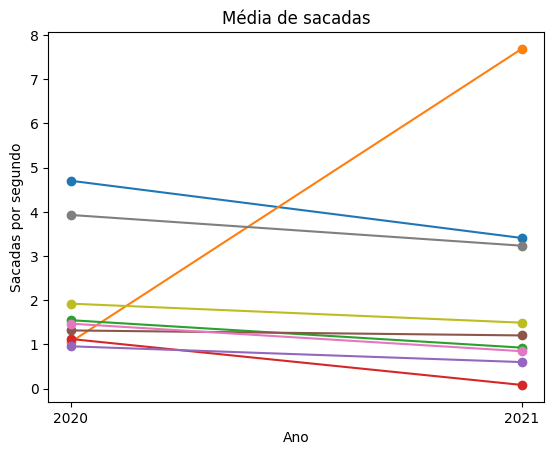

In [44]:
for index,row in resultado.iterrows():
    plt.plot([2020,2021],[row["Saccade_20_ps"],row["Saccade_21_ps"]],"o-")
plt.title("Média de sacadas")
plt.xlabel("Ano")
plt.ylabel("Sacadas por segundo")
plt.xticks([2020,2021])

In [45]:
print(resultado["Saccade_20_ps"].corr(resultado["Acerto L_20"]))
print(resultado["Saccade_21_ps"].corr(resultado["Acerto L_21"]))

-0.349750449915873
-0.24046296156394117


# Fixações

In [47]:
fix_start = {2020:{},2021:{}}

for aluno in range(1,10):
    for ano in [2020,2021]:
        fix_start[ano]["P "+str(aluno)] = 0
        for teste in testes:
            link = "drive/MyDrive/ufabc/ET_2020_2021_CS/data_lido/"
            file = link+f"{teste}_{ano}_Aluno_{aluno}.csv"
            df = pd.read_csv(file)
            for index, row in df.iterrows():
                aois = row["AoI"].split(",")
                 #print(aois)
                for aoi_raw in aois:
                    a = str(aoi_raw)
                    if a != "-":
                        a = int(aoi_raw)
                        a_simple = a
                        if a > 9:
                            a_simple = a//10
                        if a_simple == 7:
                            fix_start[ano]["P "+str(aluno)] = row["Time"]/1000


In [48]:
resultado['Start_20'] = resultado['ID'].map(fix_start[2020])
resultado['Start_21'] = resultado['ID'].map(fix_start[2021])
resultado

,ID,Acerto V_20,Acerto L_20,Acerto V_21,Acerto L_21,Tempo_20,Tempo_21,Tempo_frase_20,Tempo_frase_21,Saccade_20,Saccade_21,Saccade_20_ps,Saccade_21_ps,Start_20,Start_21
0,P 1,9,6,6,4,40.597250,25.474667,63.162476,62.315457,297.083333,212.416667,4.703478,3.408732,32.870,16.884
1,P 2,12,7,8,5,7.208000,39.715583,61.359582,40.146662,64.666667,308.583333,1.053897,7.686401,8.666,31.540
2,P 3,8,11,9,11,14.146250,9.672750,66.479289,60.227467,102.916667,55.833333,1.548101,0.927041,19.895,4.125
3,P 4,10,7,10,1,7.542250,NaN,43.944074,56.078855,49.333333,4.666667,1.122639,0.083216,9.631,0.000
4,P 5,8,7,10,7,7.318750,7.522750,53.881610,50.544985,51.583333,30.333333,0.957346,0.600125,8.250,7.768
5,P 6,11,7,9,8,9.846083,7.804250,52.285990,52.646381,68.833333,63.333333,1.316478,1.202995,12.226,10.762
6,P 7,11,8,11,11,10.558583,6.632583,55.701699,56.831889,81.833333,48.083333,1.469135,0.846063,14.389,5.373
7,P 8,7,6,10,6,33.702000,27.487500,76.118277,74.675509,299.083333,241.500000,3.929192,3.233992,26.083,20.361
8,P 9,10,11,12,7,13.654167,10.803833,67.291785,66.746040,129.333333,99.583333,1.921978,1.491974,13.624,15.670


([<matplotlib.axis.XTick at 0x79e61c86cda0>,
 [Text(2020, 0, '2020'), Text(2021, 0, '2021')])

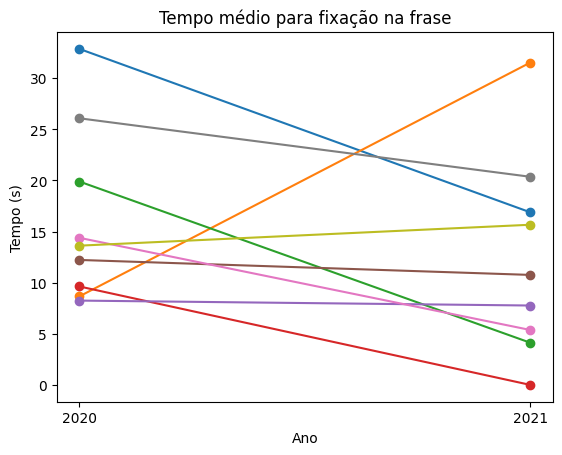

In [49]:
for index,row in resultado.iterrows():
    plt.plot([2020,2021],[row["Start_20"],row["Start_21"]],"o-")
plt.title("Tempo médio para fixação na frase")
plt.xlabel("Ano")
plt.ylabel("Tempo (s)")
plt.xticks([2020,2021])

In [50]:
print(resultado["Start_20"].corr(resultado["Acerto L_20"]))
print(resultado["Start_21"].corr(resultado["Acerto L_21"]))

-0.18177287068771517
-0.19213801749924497


In [52]:
fix = {2020:{},2021:{}}

for aluno in range(1,10):
    for ano in [2020,2021]:
        fix[ano]["P "+str(aluno)] = 0
        c = 0
        for teste in testes:
            link = "drive/MyDrive/ufabc/ET_2020_2021_CS/data_lido/"
            file = link+f"{teste}_{ano}_Aluno_{aluno}.csv"
            df = pd.read_csv(file)
            previous = "-"
            for index, row in df.iterrows():
                aois = row["AoI"]
                if aois != "-" and aois!=previous:
                    c += 1
                    previous = aois
            fix[ano]["P "+str(aluno)] = c/12


In [53]:
resultado['Fix_20'] = resultado['ID'].map(fix[2020])
resultado['Fix_21'] = resultado['ID'].map(fix[2021])
resultado

,ID,Acerto V_20,Acerto L_20,Acerto V_21,Acerto L_21,Tempo_20,Tempo_21,Tempo_frase_20,Tempo_frase_21,Saccade_20,Saccade_21,Saccade_20_ps,Saccade_21_ps,Start_20,Start_21,Fix_20,Fix_21
0,P 1,9,6,6,4,40.597250,25.474667,63.162476,62.315457,297.083333,212.416667,4.703478,3.408732,32.870,16.884,304.333333,248.333333
1,P 2,12,7,8,5,7.208000,39.715583,61.359582,40.146662,64.666667,308.583333,1.053897,7.686401,8.666,31.540,52.000000,234.916667
2,P 3,8,11,9,11,14.146250,9.672750,66.479289,60.227467,102.916667,55.833333,1.548101,0.927041,19.895,4.125,96.666667,85.083333
3,P 4,10,7,10,1,7.542250,NaN,43.944074,56.078855,49.333333,4.666667,1.122639,0.083216,9.631,0.000,65.000000,56.333333
4,P 5,8,7,10,7,7.318750,7.522750,53.881610,50.544985,51.583333,30.333333,0.957346,0.600125,8.250,7.768,60.333333,67.000000
5,P 6,11,7,9,8,9.846083,7.804250,52.285990,52.646381,68.833333,63.333333,1.316478,1.202995,12.226,10.762,76.250000,56.833333
6,P 7,11,8,11,11,10.558583,6.632583,55.701699,56.831889,81.833333,48.083333,1.469135,0.846063,14.389,5.373,70.750000,52.250000
7,P 8,7,6,10,6,33.702000,27.487500,76.118277,74.675509,299.083333,241.500000,3.929192,3.233992,26.083,20.361,167.250000,147.000000
8,P 9,10,11,12,7,13.654167,10.803833,67.291785,66.746040,129.333333,99.583333,1.921978,1.491974,13.624,15.670,108.583333,75.333333


([<matplotlib.axis.XTick at 0x79e61c9af110>,
 [Text(2020, 0, '2020'), Text(2021, 0, '2021')])

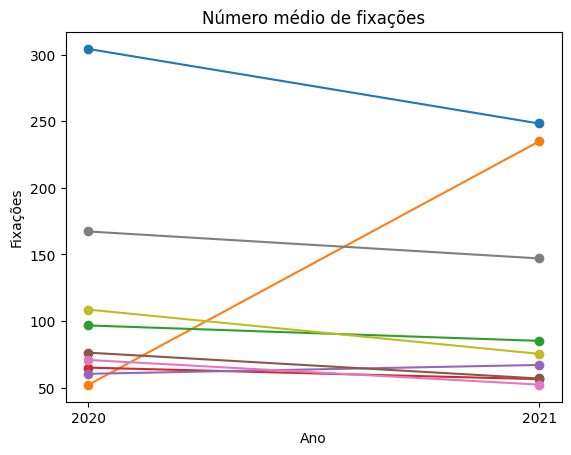

In [54]:
for index,row in resultado.iterrows():
    plt.plot([2020,2021],[row["Fix_20"],row["Fix_21"]],"o-")
plt.title("Número médio de fixações")
plt.xlabel("Ano")
plt.ylabel("Fixações")
plt.xticks([2020,2021])

In [55]:
print(resultado["Fix_20"].corr(resultado["Acerto L_20"]))
print(resultado["Fix_21"].corr(resultado["Acerto L_21"]))

-0.2899082709032882
-0.37662581131624834


In [56]:
print(resultado["Fix_20"].mean())
print(resultado["Fix_21"].mean())

111.24074074074075
113.67592592592592


In [57]:
visit = {2020:{"imagem":{},"frase":{}},2021:{"imagem":{},"frase":{}}}
for aluno_num in range(1,10):
    aluno = "P "+str(aluno_num)
    for ano in [2020,2021]:
        visit[ano]["imagem"][aluno] = 0
        visit[ano]["frase"][aluno] = 0
        for teste in testes:
            file = link+f"{teste}_{ano}_Aluno_{aluno_num}.csv"
            df_aluno = pd.read_csv(file)
            previous = "-"
            for index, row in df_aluno.iterrows():
                aois = row["AoI"]
                if aois != "-" and aois != previous:
                    aois_list = aois.split(",")
                    previous_list = previous.split(",")
                    new = []
                    old = []
                    for aoi_raw in aois_list:
                        a = str(aoi_raw)
                        if a != "-":
                            a = int(aoi_raw)
                            a_simple = a
                            if a > 9:
                                a_simple = a//10
                            new.append(a_simple)
                    for aoi_raw in previous_list:
                        a = str(aoi_raw)
                        if a != "-":
                            a = int(aoi_raw)
                            a_simple = a
                            if a > 9:
                                a_simple = a//10
                            old.append(a_simple)
                    for item in new:
                        if item not in old and item in [3,4,5,6,7]:
                            if item in [3,4,5,6]:
                                visit[ano]["imagem"][aluno] += 1/12
                            else:
                                visit[ano]["frase"][aluno] += 1/12
                    previous = aois


In [58]:
visit

{2020: {'imagem': {'P 1': 52.166666666667055,
   'P 2': 6.583333333333327,
   'P 3': 12.250000000000018,
   'P 4': 13.166666666666691,
   'P 5': 8.999999999999995,
   'P 6': 11.66666666666668,
   'P 7': 11.750000000000014,
   'P 8': 15.583333333333375,
   'P 9': 8.416666666666657},
  'frase': {'P 1': 62.250000000000675,
   'P 2': 10.250000000000004,
   'P 3': 16.583333333333368,
   'P 4': 17.250000000000025,
   'P 5': 8.749999999999993,
   'P 6': 20.416666666666647,
   'P 7': 10.083333333333336,
   'P 8': 27.249999999999883,
   'P 9': 9.416666666666664}},
 2021: {'imagem': {'P 1': 35.499999999999915,
   'P 2': 56.416666666667176,
   'P 3': 12.08333333333335,
   'P 4': 17.41666666666669,
   'P 5': 14.166666666666698,
   'P 6': 12.333333333333352,
   'P 7': 6.333333333333328,
   'P 8': 17.583333333333353,
   'P 9': 8.91666666666666},
  'frase': {'P 1': 71.91666666666694,
   'P 2': 106.166666666665,
   'P 3': 16.6666666666667,
   'P 4': 26.33333333333323,
   'P 5': 16.750000000000032,
   

In [59]:
resultado['Visit_Imagem_20'] = resultado['ID'].map(visit[2020]["imagem"])
resultado['Visit_Imagem_21'] = resultado['ID'].map(visit[2021]["imagem"])
resultado['Visit_Frase_20'] = resultado['ID'].map(visit[2020]["frase"])
resultado['Visit_Frase_21'] = resultado['ID'].map(visit[2021]["frase"])
resultado

,ID,Acerto V_20,Acerto L_20,Acerto V_21,Acerto L_21,Tempo_20,Tempo_21,Tempo_frase_20,Tempo_frase_21,Saccade_20,...,Saccade_20_ps,Saccade_21_ps,Start_20,Start_21,Fix_20,Fix_21,Visit_Imagem_20,Visit_Imagem_21,Visit_Frase_20,Visit_Frase_21
0,P 1,9,6,6,4,40.597250,25.474667,63.162476,62.315457,297.083333,...,4.703478,3.408732,32.870,16.884,304.333333,248.333333,52.166667,35.500000,62.250000,71.916667
1,P 2,12,7,8,5,7.208000,39.715583,61.359582,40.146662,64.666667,...,1.053897,7.686401,8.666,31.540,52.000000,234.916667,6.583333,56.416667,10.250000,106.166667
2,P 3,8,11,9,11,14.146250,9.672750,66.479289,60.227467,102.916667,...,1.548101,0.927041,19.895,4.125,96.666667,85.083333,12.250000,12.083333,16.583333,16.666667
3,P 4,10,7,10,1,7.542250,NaN,43.944074,56.078855,49.333333,...,1.122639,0.083216,9.631,0.000,65.000000,56.333333,13.166667,17.416667,17.250000,26.333333
4,P 5,8,7,10,7,7.318750,7.522750,53.881610,50.544985,51.583333,...,0.957346,0.600125,8.250,7.768,60.333333,67.000000,9.000000,14.166667,8.750000,16.750000
5,P 6,11,7,9,8,9.846083,7.804250,52.285990,52.646381,68.833333,...,1.316478,1.202995,12.226,10.762,76.250000,56.833333,11.666667,12.333333,20.416667,8.833333
6,P 7,11,8,11,11,10.558583,6.632583,55.701699,56.831889,81.833333,...,1.469135,0.846063,14.389,5.373,70.750000,52.250000,11.750000,6.333333,10.083333,5.750000
7,P 8,7,6,10,6,33.702000,27.487500,76.118277,74.675509,299.083333,...,3.929192,3.233992,26.083,20.361,167.250000,147.000000,15.583333,17.583333,27.250000,17.750000
8,P 9,10,11,12,7,13.654167,10.803833,67.291785,66.746040,129.333333,...,1.921978,1.491974,13.624,15.670,108.583333,75.333333,8.416667,8.916667,9.416667,11.583333


([<matplotlib.axis.XTick at 0x79e61ca52fc0>,
 [Text(2020, 0, '2020'), Text(2021, 0, '2021')])

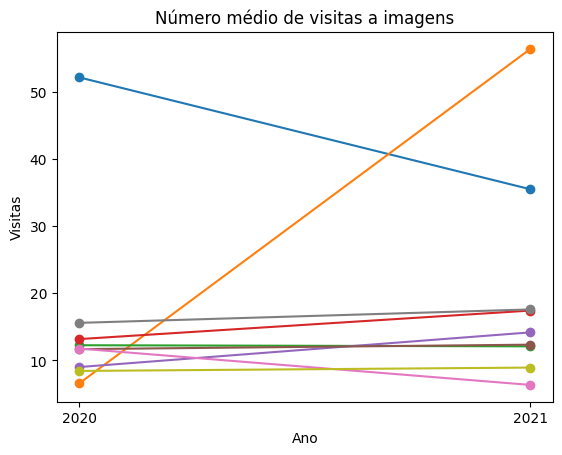

In [60]:
for index,row in resultado.iterrows():
    plt.plot([2020,2021],[row["Visit_Imagem_20"],row["Visit_Imagem_21"]],"o-")
plt.title("Número médio de visitas a imagens")
plt.xlabel("Ano")
plt.ylabel("Visitas")
plt.xticks([2020,2021])

In [61]:
print(resultado["Visit_Imagem_20"].corr(resultado["Acerto L_20"]))
print(resultado["Visit_Imagem_21"].corr(resultado["Acerto L_21"]))

-0.3849070853477187
-0.4767176414911953


In [62]:
print(resultado["Visit_Frase_20"].corr(resultado["Acerto L_20"]))
print(resultado["Visit_Frase_21"].corr(resultado["Acerto L_21"]))

-0.4505202580343229
-0.4677360095812988


In [63]:
entropy = {2020:{},2021:{}}
for aluno in range(1,10):
    for ano in [2020,2021]:
        test_entropies = []
        for teste in testes:
            link = "drive/MyDrive/ufabc/ET_2020_2021_CS/data_lido/"
            file = link+f"{teste}_{ano}_Aluno_{aluno}.csv"
            df = pd.read_csv(file)
            grid_counts = {}
            for index, row in df.iterrows():
                if row["AoI"] != "-":
                    grid_x = row["X"] // 75
                    grid_y = row["Y"] // 75
                    grid_cell = (grid_x, grid_y)
                    grid_counts[grid_cell] = grid_counts.get(grid_cell, 0) + 1
            total_fixations = sum(grid_counts.values())
            if total_fixations > 0:
                entropy_val = -sum((count/total_fixations) * np.log2(count/total_fixations) for count in grid_counts.values())
                test_entropies.append(entropy_val)
        entropy[ano]["P "+str(aluno)] = np.mean(test_entropies) if test_entropies else 0

In [64]:
entropy

{2020: {'P 1': np.float64(4.471879119654616),
  'P 2': np.float64(3.8478466480598943),
  'P 3': np.float64(4.416920302346942),
  'P 4': np.float64(4.152493813217293),
  'P 5': np.float64(4.060879781897465),
  'P 6': np.float64(4.005954985381428),
  'P 7': np.float64(4.09852821668858),
  'P 8': np.float64(3.9864869821740427),
  'P 9': np.float64(3.989158749100675)},
 2021: {'P 1': np.float64(4.146188329919932),
  'P 2': np.float64(4.108227522368438),
  'P 3': np.float64(4.385694336927586),
  'P 4': np.float64(2.8085702833480983),
  'P 5': np.float64(4.073921106970254),
  'P 6': np.float64(4.201799917237792),
  'P 7': np.float64(4.103676108314304),
  'P 8': np.float64(3.9086131966199082),
  'P 9': np.float64(3.982218587003292)}}

In [65]:
resultado['Entropy_20'] = resultado['ID'].map(entropy[2020])
resultado['Entropy_21'] = resultado['ID'].map(entropy[2021])
resultado

,ID,Acerto V_20,Acerto L_20,Acerto V_21,Acerto L_21,Tempo_20,Tempo_21,Tempo_frase_20,Tempo_frase_21,Saccade_20,...,Start_20,Start_21,Fix_20,Fix_21,Visit_Imagem_20,Visit_Imagem_21,Visit_Frase_20,Visit_Frase_21,Entropy_20,Entropy_21
0,P 1,9,6,6,4,40.597250,25.474667,63.162476,62.315457,297.083333,...,32.870,16.884,304.333333,248.333333,52.166667,35.500000,62.250000,71.916667,4.471879,4.146188
1,P 2,12,7,8,5,7.208000,39.715583,61.359582,40.146662,64.666667,...,8.666,31.540,52.000000,234.916667,6.583333,56.416667,10.250000,106.166667,3.847847,4.108228
2,P 3,8,11,9,11,14.146250,9.672750,66.479289,60.227467,102.916667,...,19.895,4.125,96.666667,85.083333,12.250000,12.083333,16.583333,16.666667,4.416920,4.385694
3,P 4,10,7,10,1,7.542250,NaN,43.944074,56.078855,49.333333,...,9.631,0.000,65.000000,56.333333,13.166667,17.416667,17.250000,26.333333,4.152494,2.808570
4,P 5,8,7,10,7,7.318750,7.522750,53.881610,50.544985,51.583333,...,8.250,7.768,60.333333,67.000000,9.000000,14.166667,8.750000,16.750000,4.060880,4.073921
5,P 6,11,7,9,8,9.846083,7.804250,52.285990,52.646381,68.833333,...,12.226,10.762,76.250000,56.833333,11.666667,12.333333,20.416667,8.833333,4.005955,4.201800
6,P 7,11,8,11,11,10.558583,6.632583,55.701699,56.831889,81.833333,...,14.389,5.373,70.750000,52.250000,11.750000,6.333333,10.083333,5.750000,4.098528,4.103676
7,P 8,7,6,10,6,33.702000,27.487500,76.118277,74.675509,299.083333,...,26.083,20.361,167.250000,147.000000,15.583333,17.583333,27.250000,17.750000,3.986487,3.908613
8,P 9,10,11,12,7,13.654167,10.803833,67.291785,66.746040,129.333333,...,13.624,15.670,108.583333,75.333333,8.416667,8.916667,9.416667,11.583333,3.989159,3.982219


([<matplotlib.axis.XTick at 0x79e61d537d40>,
 [Text(2020, 0, '2020'), Text(2021, 0, '2021')])

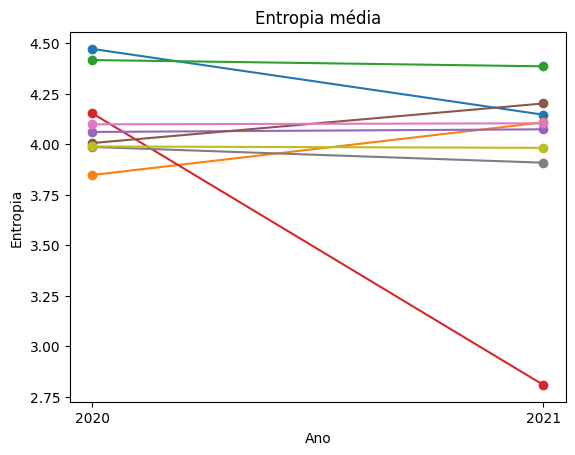

In [66]:
for index,row in resultado.iterrows():
    plt.plot([2020,2021],[row["Entropy_20"],row["Entropy_21"]],"o-")
plt.title("Entropia média")
plt.xlabel("Ano")
plt.ylabel("Entropia")
plt.xticks([2020,2021])

In [67]:
resultado.to_csv("analises.csv",index=False)